# ESS Battery Cycle Life — EDA

다섯 가지 EDA 질문을 Batch 1·2·3에서 비교하고, 확인한 결과를 Feature 설계와 검증 전략으로 연결한다.

In [1]:
from pathlib import Path
import sys
import json
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RESULTS = ROOT / 'results'


## 1. Data Load / Structure

In [2]:
summary = pd.read_csv(RESULTS/'tables/cycle_life_summary.csv')
summary

,batch,count,mean,median,std,min,max,short_pct,middle_pct,long_pct
0,Batch1,41,838.585366,842.0,194.892788,534.0,1227.0,0.000000,75.609756,24.390244
1,Batch2,34,550.705882,468.5,221.641196,392.0,1186.0,76.470588,14.705882,8.823529
2,Batch3,40,1032.000000,964.5,308.598403,541.0,1935.0,0.000000,52.500000,47.500000


## 2. Q1 — Cycle Life Distribution

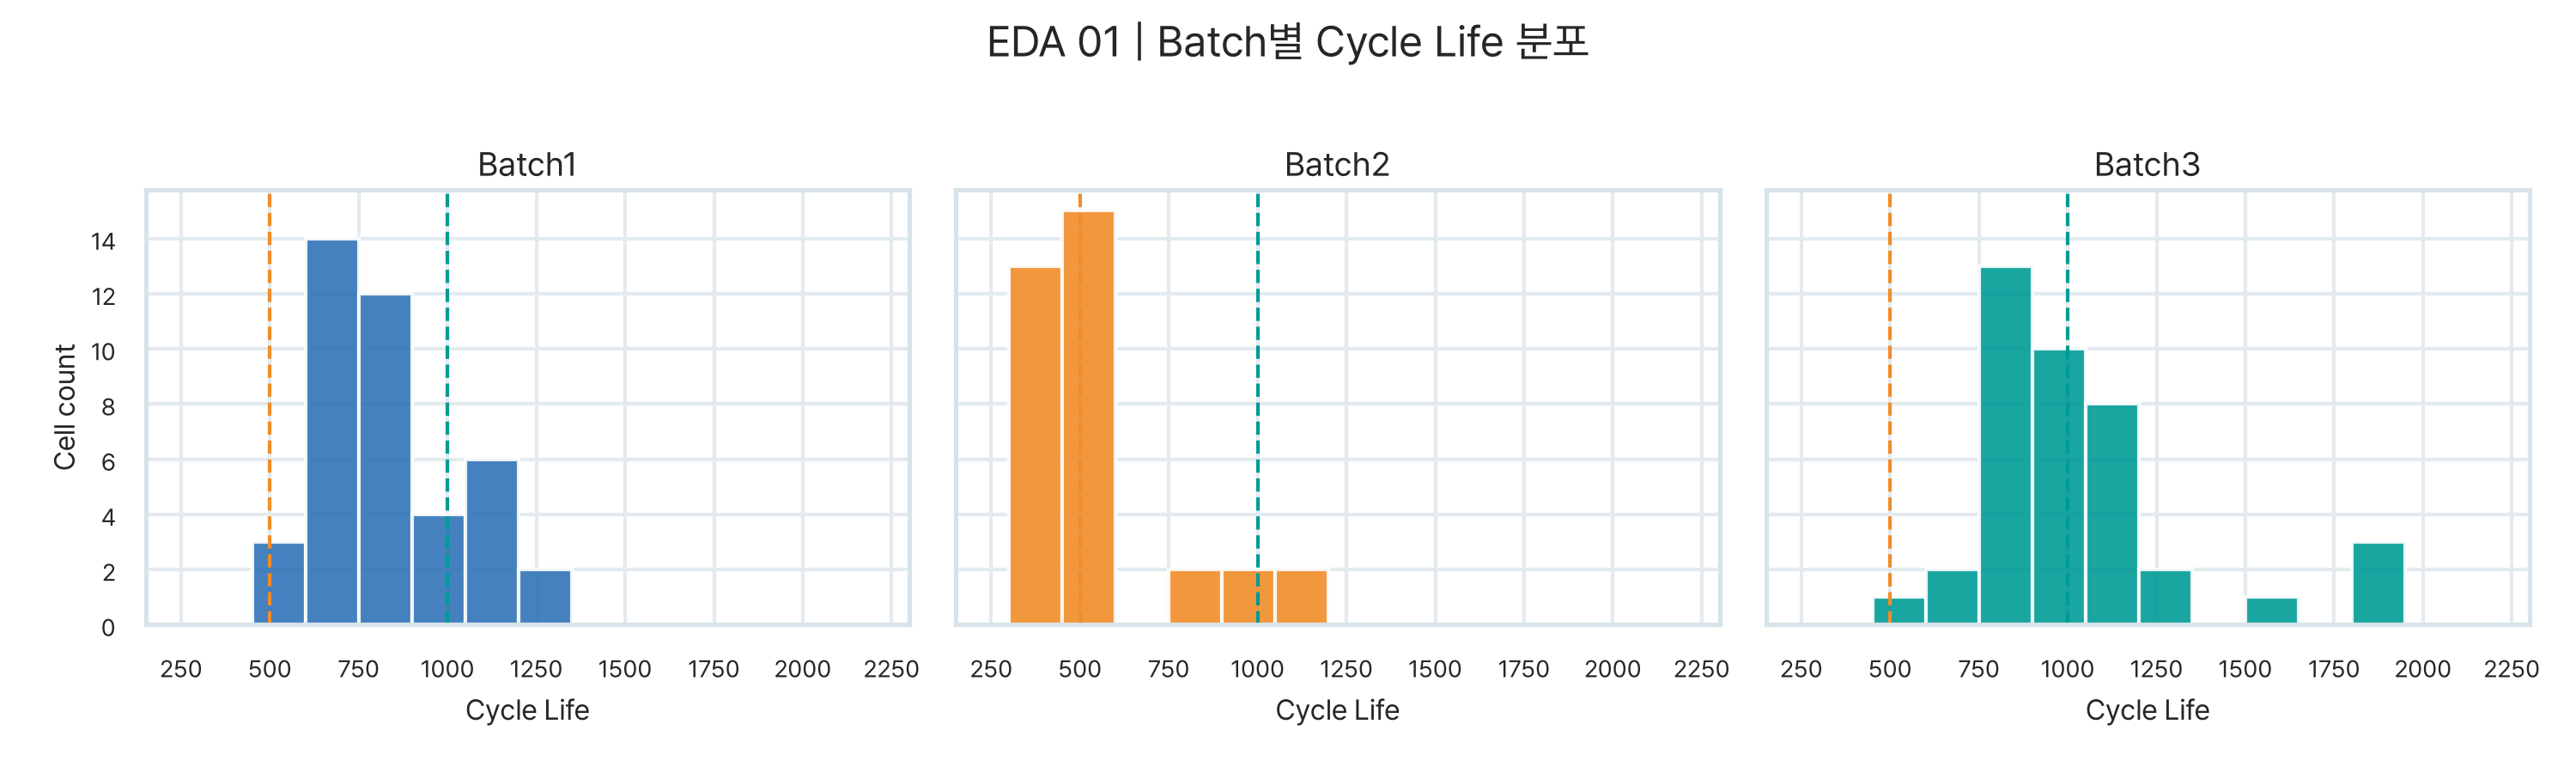

In [3]:
display(Image(filename=RESULTS/'figures/day1_eda01_cycle_life_by_batch.png'))

Batch 2는 단수명 비중이 크고 Batch 3는 장수명 비중이 커서 Batch 1과 뚜렷한 분포 이동이 존재한다.

## 3. Q2 — Capacity Degradation

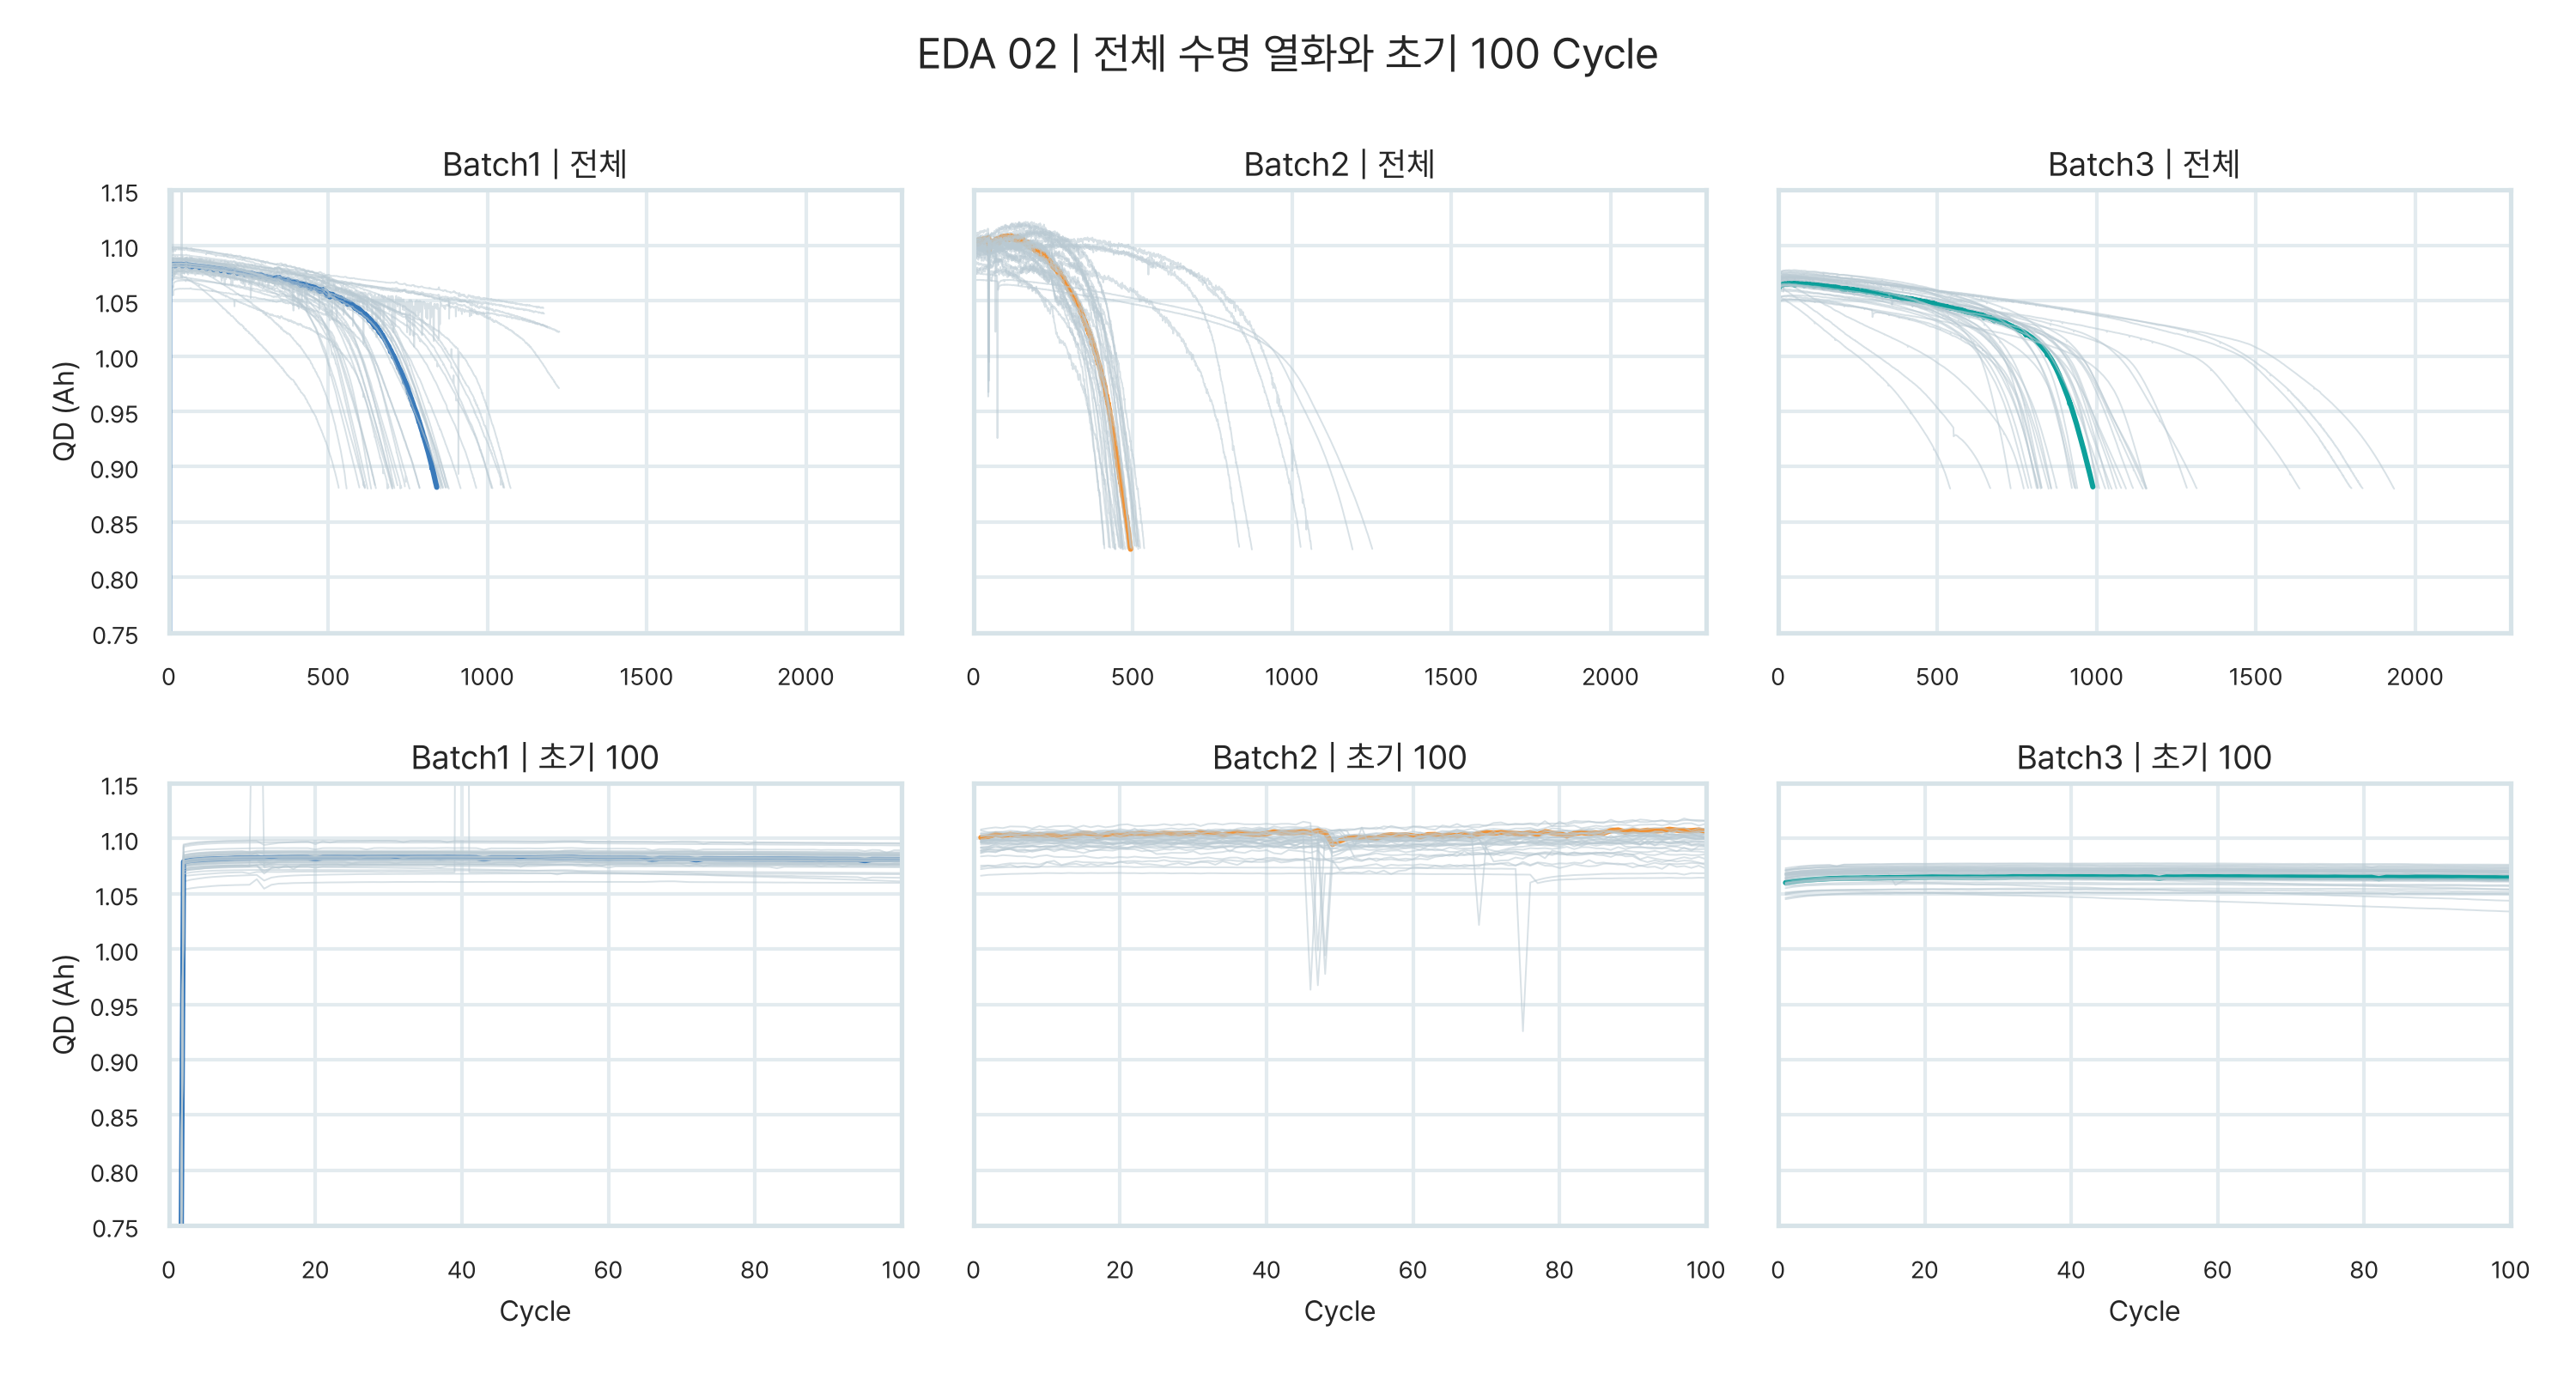

,knee_median_cycle,knee_median_fraction
Batch1,549.0,0.709091
Batch2,323.0,0.692716
Batch3,753.5,0.757302


In [4]:
display(Image(filename=RESULTS/'figures/day1_eda02_qd_degradation_by_batch.png'))
evidence = json.loads((RESULTS/'tables/day1_batch_comparison.json').read_text())
pd.DataFrame({b: {'knee_median_cycle': v['knee_median_cycle'], 'knee_median_fraction': v['knee_median_fraction']} for b, v in evidence['batches'].items()}).T

전체 수명 곡선에서 계산한 Knee 중앙값은 Batch 1 549, Batch 2 323, Batch 3 753.5 Cycle이다. 이는 열화 시점 차이를 설명하는 사후 지표이며 미래 정보를 사용하므로 모델 Feature에서 제외한다. 초기 QD 절대값보다 초기 변화량과 ΔQ(V)를 사용한다.

## 4. Q3 — ΔQ(V)

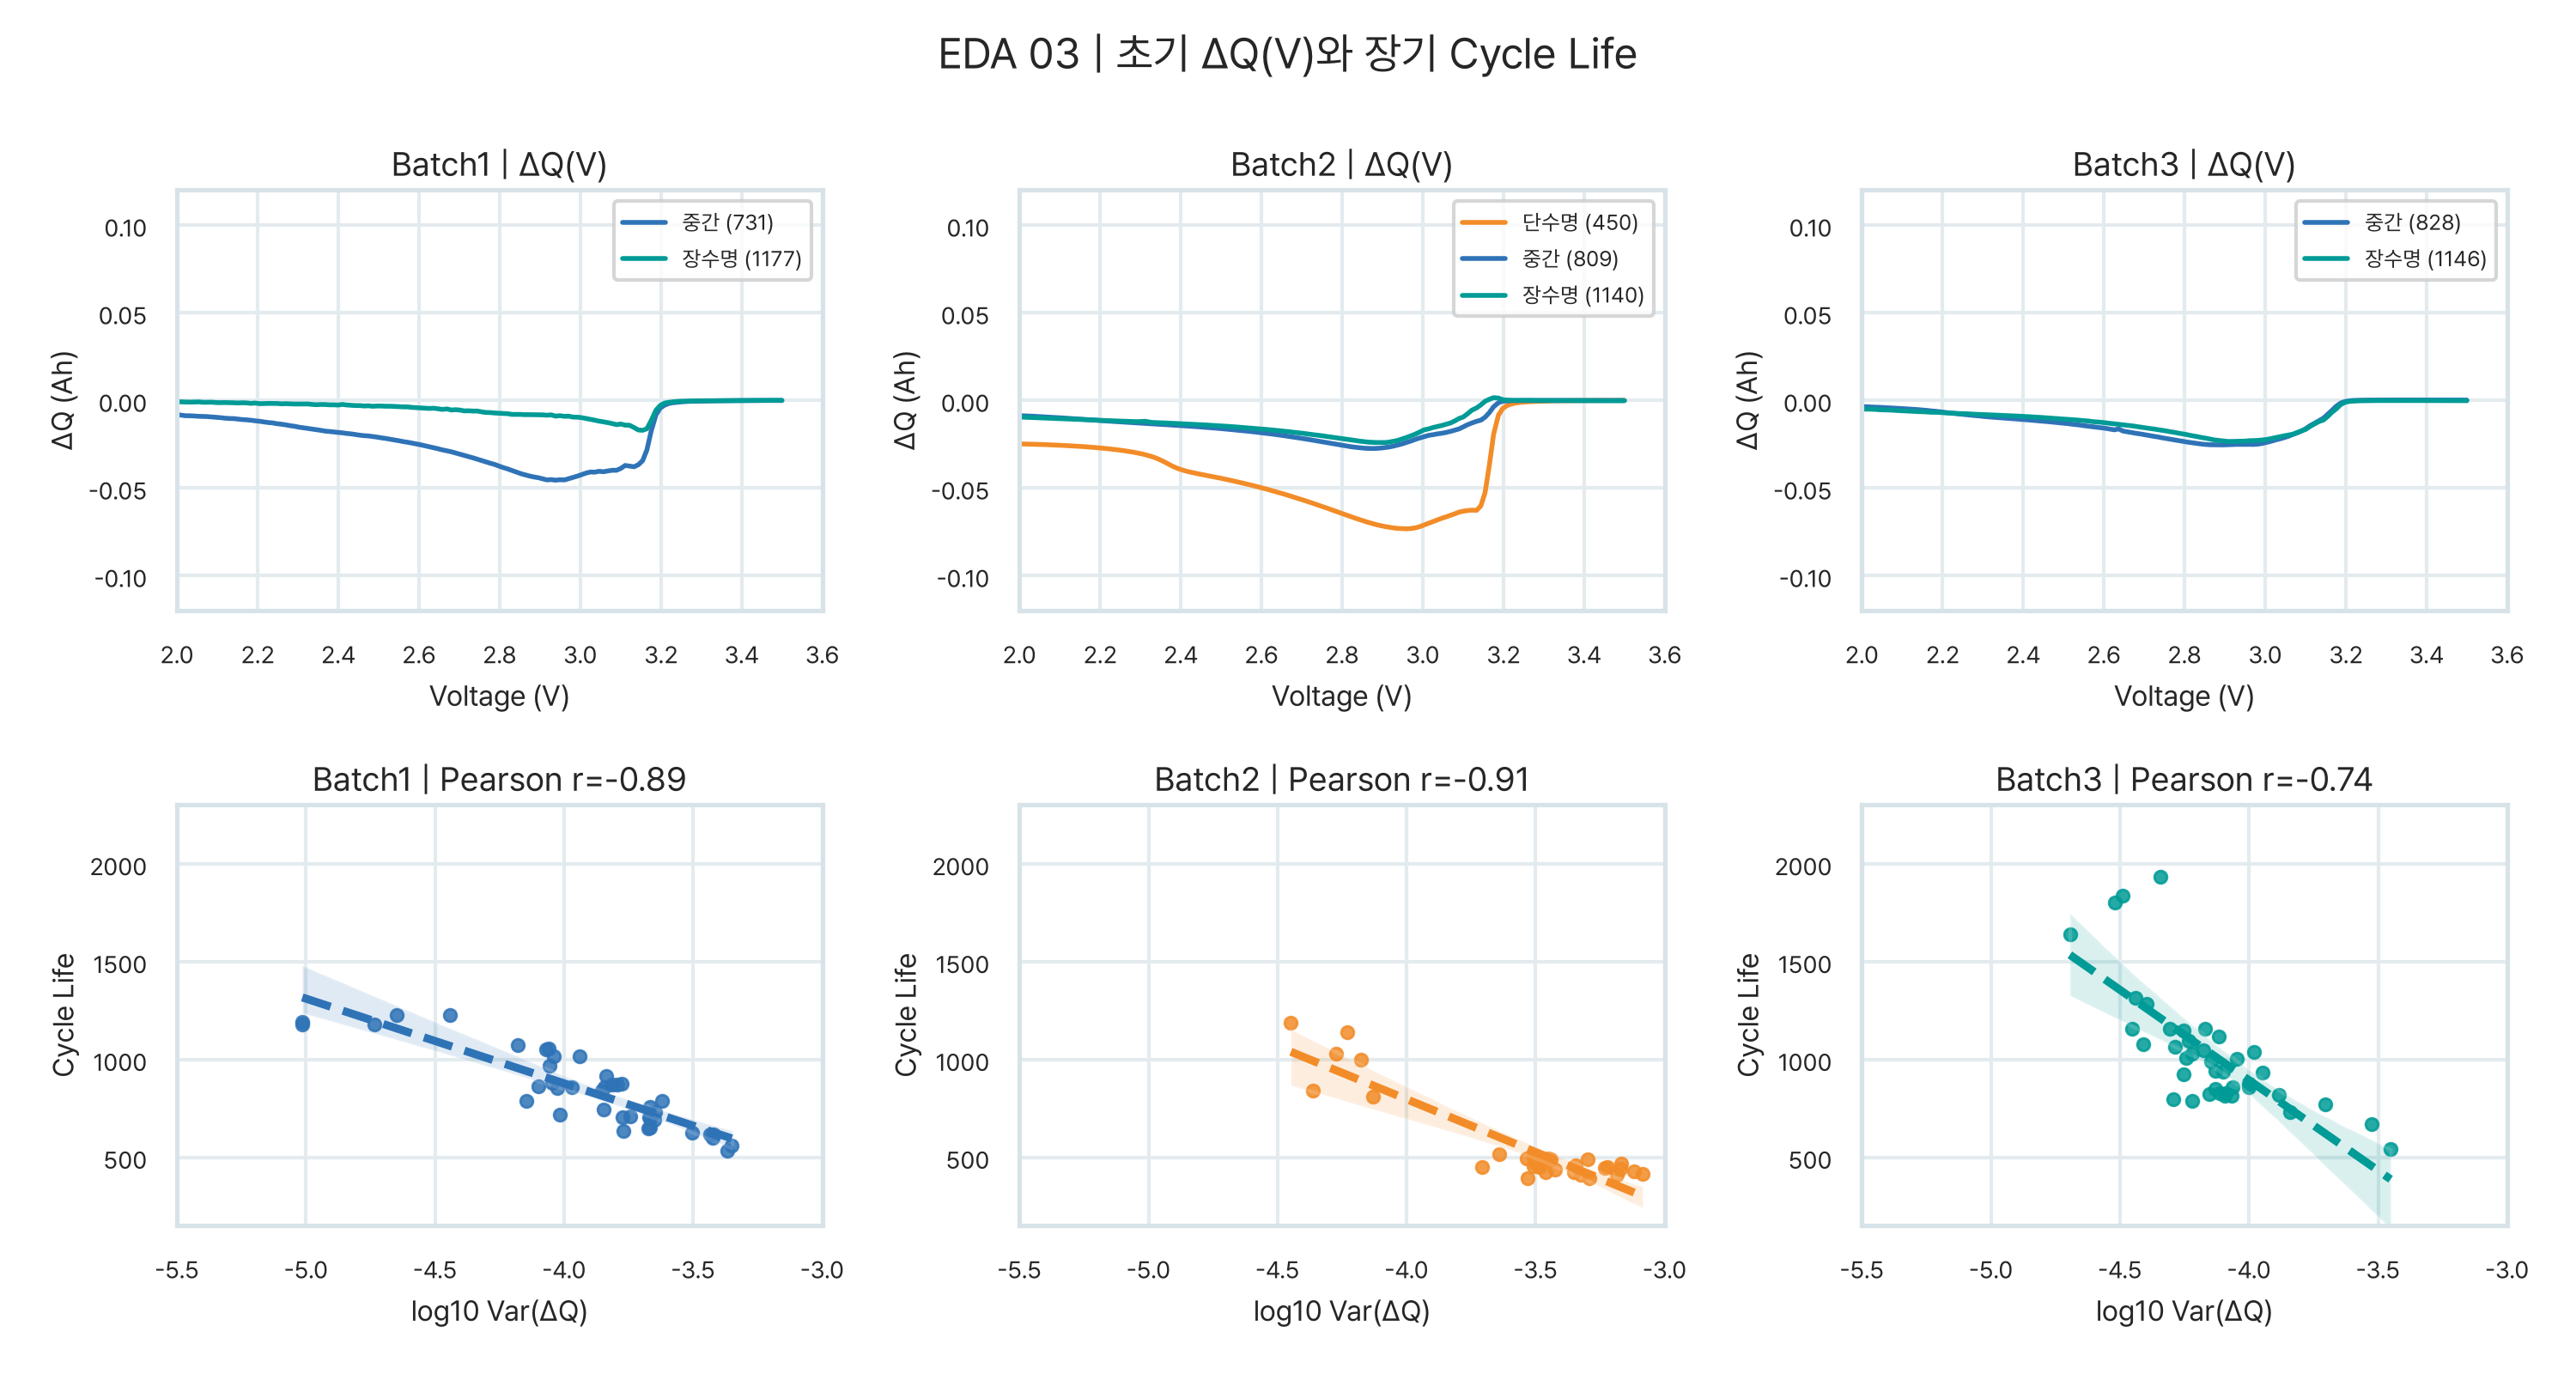

,feature,pearson,spearman
1,log_dq_var,-0.885847,-0.87978


In [5]:
display(Image(filename=RESULTS/'figures/day1_eda03_delta_q_by_batch.png'))
corr = pd.read_csv(RESULTS/'tables/feature_target_correlations.csv'); corr[corr.feature=='log_dq_var']

## 5. Q4 — Charging Policy

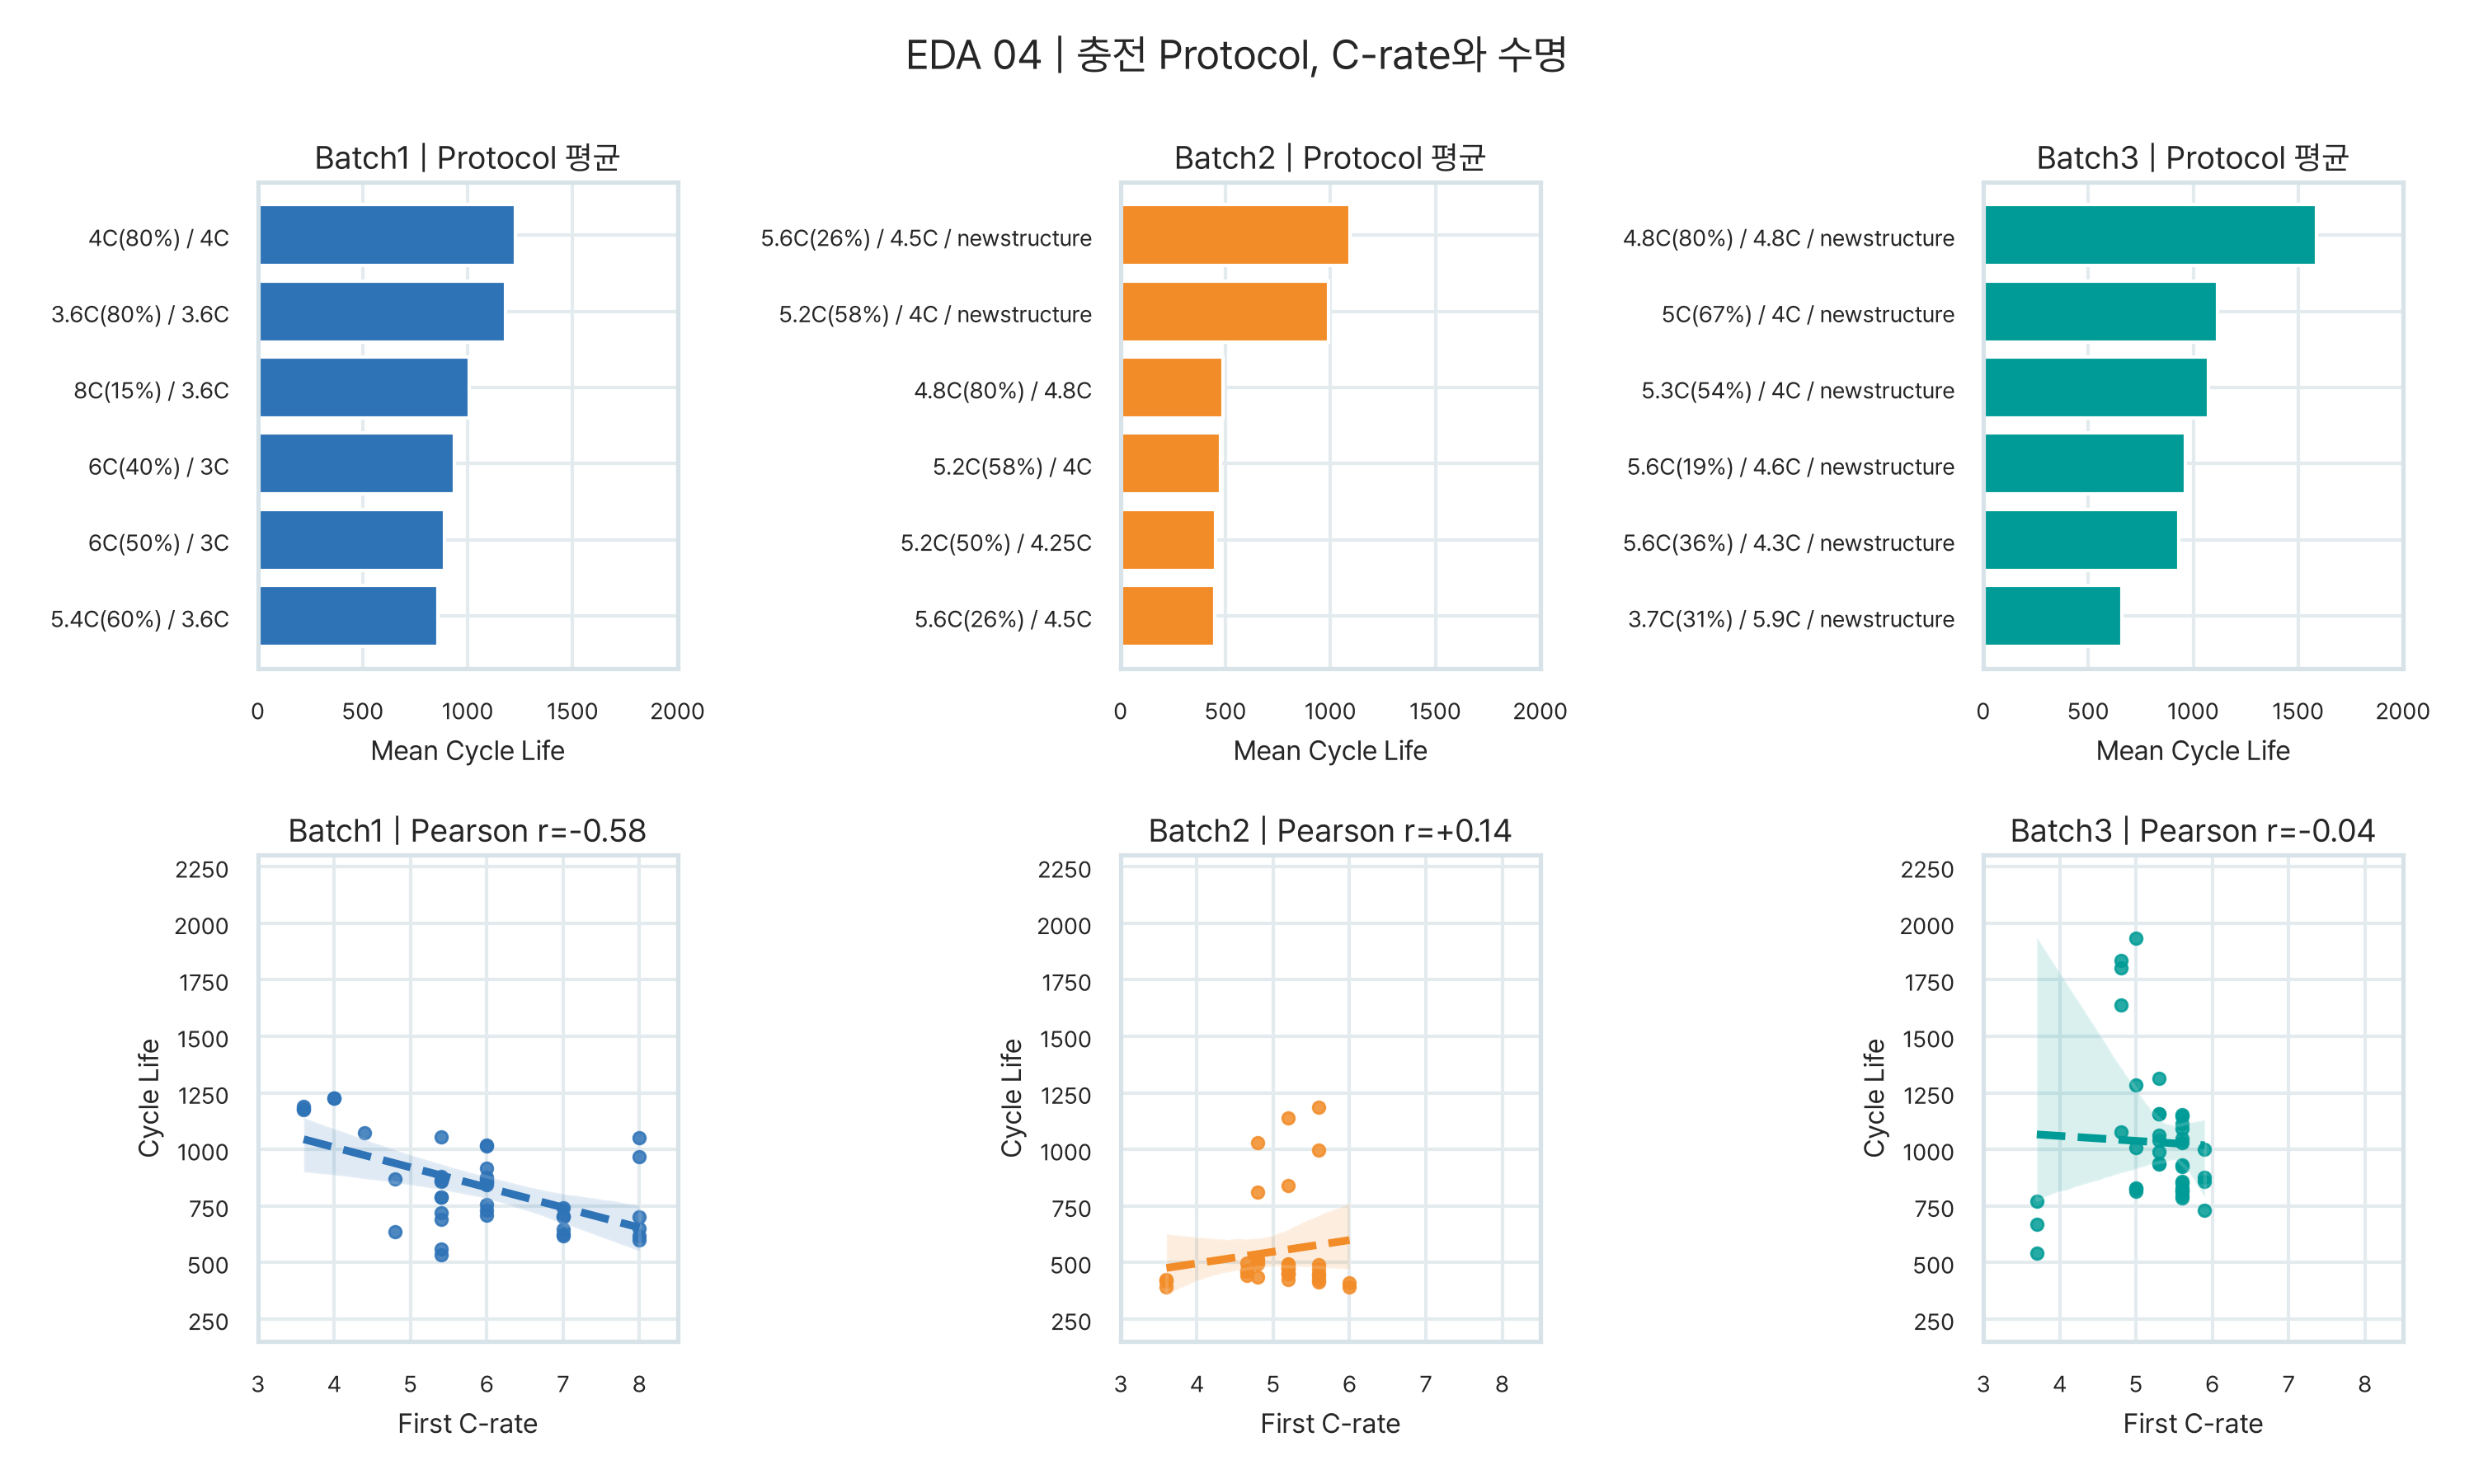

,batch,policy,label,n,mean,std
0,Batch1,3.6C(80%)-3.6C,3.6C(80%) / 3.6C,3,1182.000,7.000000
1,Batch2,5.6C(26%)-4.5C,5.6C(26%) / 4.5C,6,448.500,29.125590
2,Batch3,5.3C(54%)-4C-newstructure,5.3C(54%) / 4C / newstructure,8,1074.375,129.674248


In [6]:
display(Image(filename=RESULTS/'figures/day1_eda04_charging_by_batch.png'))
rows=[]
for batch, values in evidence['batches'].items():
    top=max(values['charging_policy'], key=lambda x: x['n'])
    rows.append({'batch': batch, **top})
pd.DataFrame(rows)

표본이 가장 많은 대표 Protocol 평균은 Batch 1 1,182.0, Batch 2 448.5, Batch 3 1,074.4 Cycle이다. Batch 구성과 표본 수가 함께 다르므로 C-rate만의 인과효과로 해석하지 않는다.

## 6. Q5 — Correlation / Conclusions

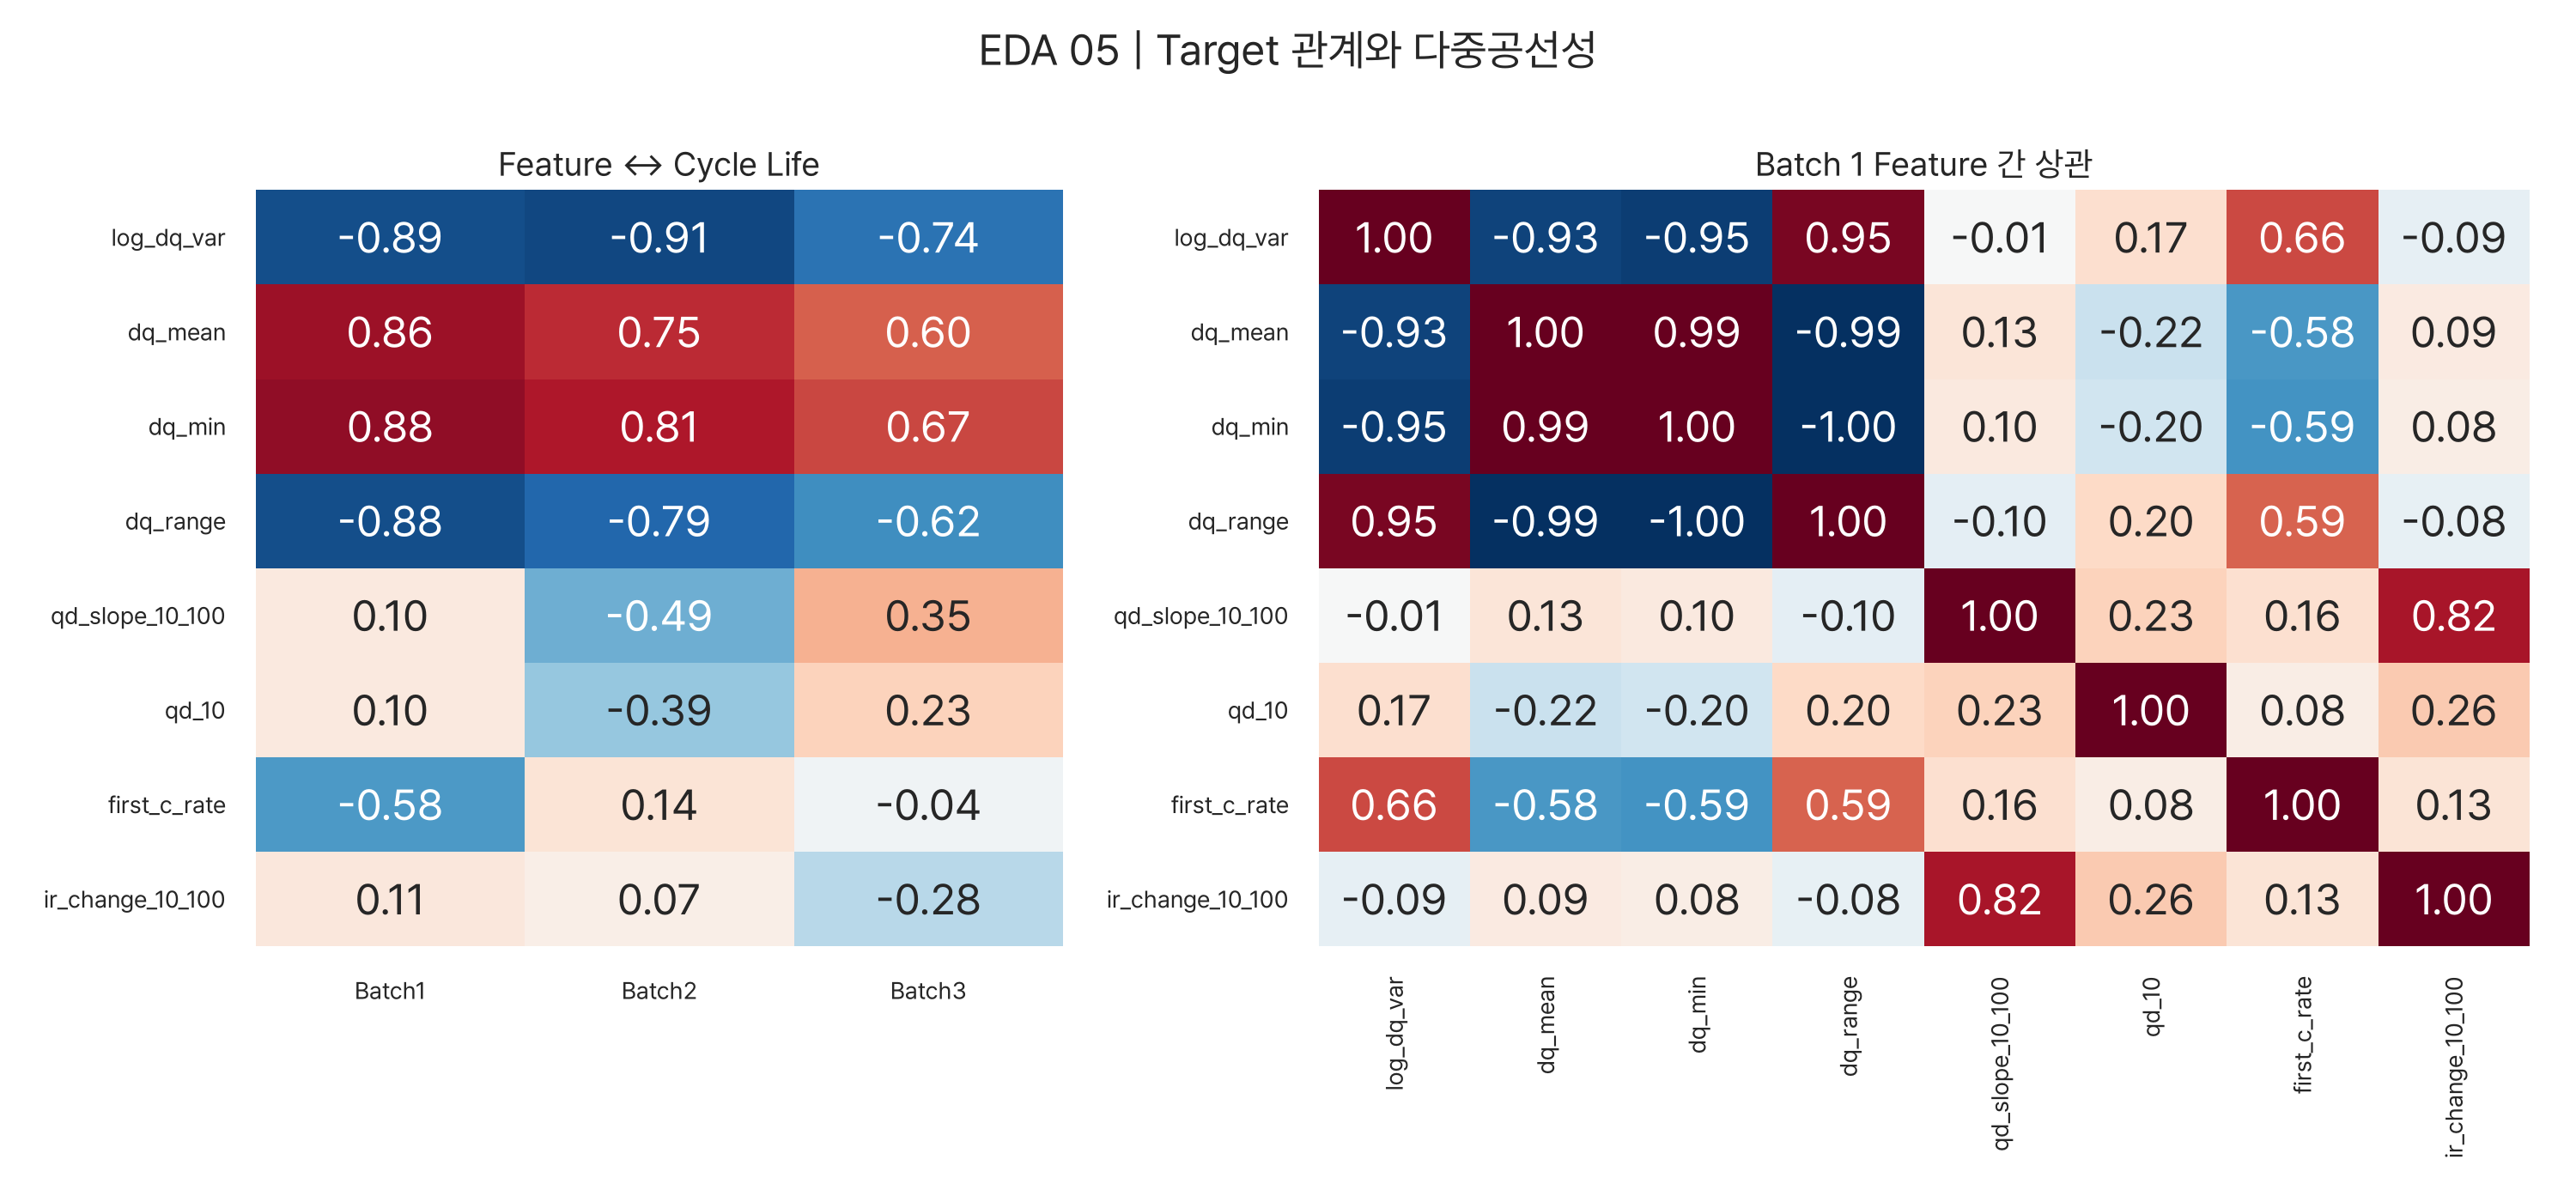

In [7]:
display(Image(filename=RESULTS/'figures/day1_eda05_correlation_strategy.png'))

ΔQ 파생 변수끼리 다중공선성이 크므로 정규화 선형 모델을 주 후보로 비교하고, 외부 배치는 선택·튜닝에 사용하지 않는다.